In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Handling imbalance
from imblearn.over_sampling import SMOTE

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving APL_Logistics.xlsx to APL_Logistics.xlsx


In [ ]:
df = pd.read_excel("APL_Logistics.xlsx")

df.head()

,Customer Id,Customer Fname,Customer Lname,Custome name,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,1.0,Richard,Hernandez,Richard Hernandez,DEBIT,6.0,4.0,159.69,472.45,Late delivery,...,5.0,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,2.0,Mary,Barrett,Mary Barrett,DEBIT,4.0,4.0,48.71,167.96,Shipping on time,...,5.0,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,2.0,Mary,Barrett,Mary Barrett,DEBIT,4.0,4.0,87.36,181.99,Shipping on time,...,1.0,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,2.0,Mary,Barrett,Mary Barrett,DEBIT,6.0,4.0,-41.89,175.99,Late delivery,...,1.0,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,2.0,Mary,Barrett,Mary Barrett,DEBIT,6.0,4.0,10.00,40.00,Late delivery,...,1.0,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class


#**Data Understanding**

In [ ]:
df.shape
df.columns.tolist()
df.head()
df.tail()
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 41 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   Customer Id                    180519 non-null   float64
 1   Customer Fname                 180519 non-null   object 
 2   Customer Lname                 180511 non-null   object 
 3   Custome name                   1048575 non-null  object 
 4   Type                           180519 non-null   object 
 5   Days for shipping (real)       180519 non-null   float64
 6   Days for shipment (scheduled)  180519 non-null   float64
 7   Benefit per order              180519 non-null   float64
 8   Sales per customer             180519 non-null   float64
 9   Delivery Status                180519 non-null   object 
 10  Late_delivery_risk             180519 non-null   float64
 11  Category Id                    180519 non-null   float64
 12  Category Name 

np.int64(868055)

#**Data Quality Check**

**Missing Values**

In [ ]:
missing = df.isnull().sum()

missing[missing > 0]

,0
Customer Id,868056
Customer Fname,868056
Customer Lname,868064
Type,868056
Days for shipping (real),868056
Days for shipment (scheduled),868056
Benefit per order,868056
Sales per customer,868056
Delivery Status,868056
Late_delivery_risk,868056


**Duplicate Rows**

In [ ]:
df.duplicated().sum()

np.int64(868055)

**Duplicate percentage**

In [ ]:
(df.duplicated().sum()/len(df))*100

np.float64(82.78425482202036)

**Unique Values**

In [ ]:
for col in df.columns:
    print(col, ":", df[col].nunique())

Customer Id : 20652
Customer Fname : 782
Customer Lname : 1109
Custome name : 14034
Type : 4
Days for shipping (real) : 7
Days for shipment (scheduled) : 4
Benefit per order : 21998
Sales per customer : 2927
Delivery Status : 4
Late_delivery_risk : 2
Category Id : 51
Category Name : 50
Customer City : 563
Customer Country : 2
Customer Segment : 3
Customer State : 46
Customer Street : 7458
Customer Zipcode : 996
Department Id : 11
Department Name : 11
Latitude : 11250
Longitude : 4487
Market : 5
Order City : 3597
Order Country : 164
Order Customer Id : 20652
Order Item Discount : 1017
Order Item Discount Rate : 18
Order Item Product Price : 75
Order Item Profit Ratio : 162
Order Item Quantity : 5
Sales : 193
Order Item Total : 2927
Order Profit Per Order : 21998
Order Region : 23
Order State : 1089
Order Status : 9
Product Name : 118
Product Price : 75
Shipping Mode : 4


#**Data Cleaning**

In [ ]:
df.columns = df.columns.str.strip()
df.dtypes

,0
Customer Id,float64
Customer Fname,object
Customer Lname,object
Custome name,object
Type,object
Days for shipping (real),float64
Days for shipment (scheduled),float64
Benefit per order,float64
Sales per customer,float64
Delivery Status,object


In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols] = df[num_cols].fillna(
    df[num_cols].median()
)

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

df[cat_cols] = df[cat_cols].fillna(
    df[cat_cols].mode().iloc[0]
)

#**Exploratory Data Analysis (EDA)**

**Target Distribution**

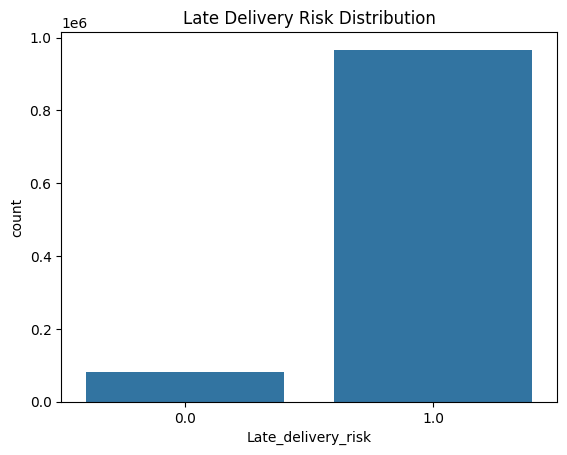

In [ ]:
sns.countplot(
    x='Late_delivery_risk',
    data=df
)

plt.title("Late Delivery Risk Distribution")
plt.show()

**Late Delivery Percentage**

In [ ]:
df['Late_delivery_risk'].value_counts(normalize=True)*100

,proportion
Late_delivery_risk,
1.0,92.223541
0.0,7.776459


**Shipping Mode Analysis**

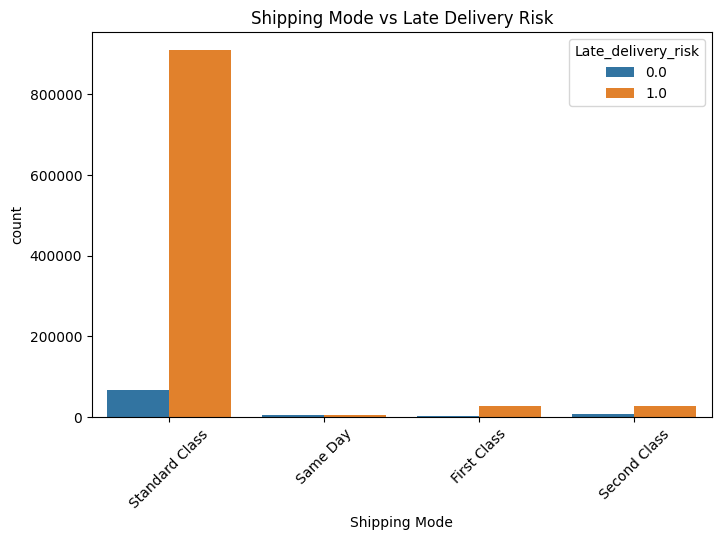

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Shipping Mode',
    hue='Late_delivery_risk',
    data=df
)

plt.xticks(rotation=45)
plt.title("Shipping Mode vs Late Delivery Risk")
plt.show()

**Region Analysis**

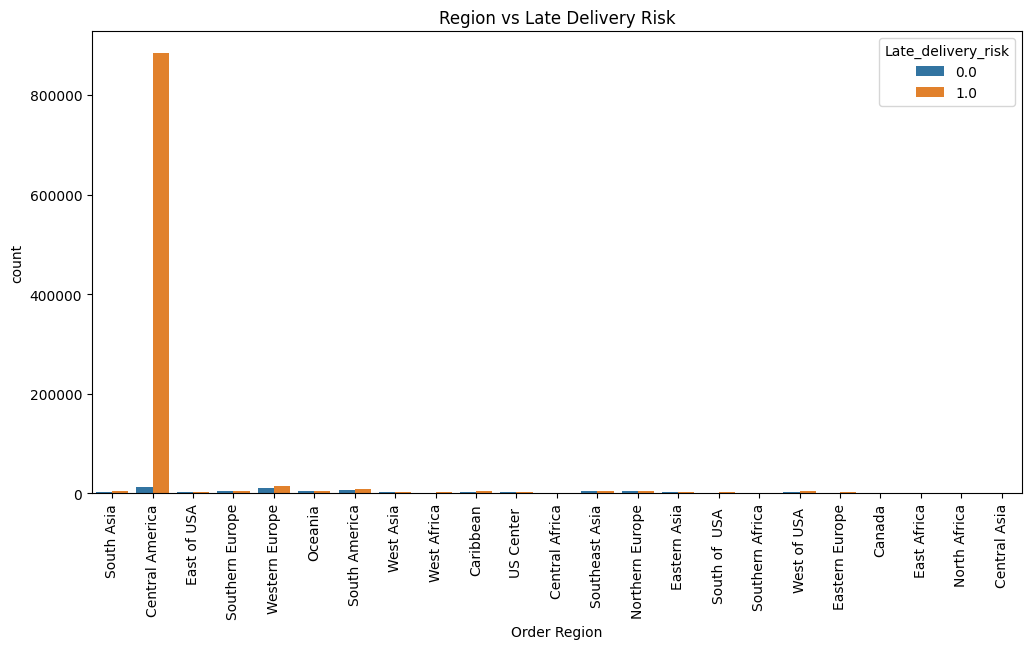

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='Order Region',
    hue='Late_delivery_risk',
    data=df
)

plt.xticks(rotation=90)
plt.title("Region vs Late Delivery Risk")
plt.show()

**Customer Segment Analysis**

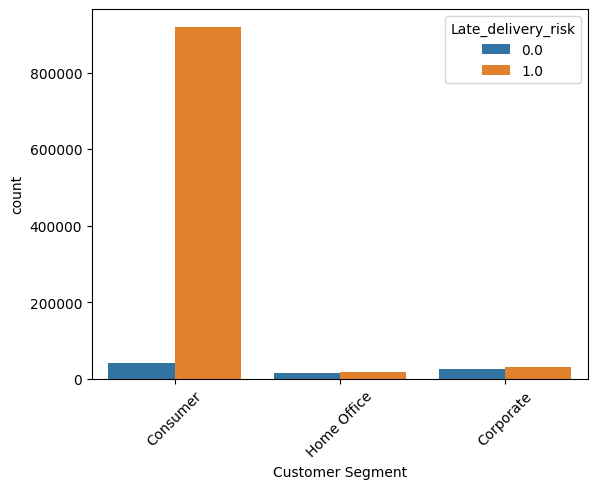

In [ ]:
sns.countplot(
    x='Customer Segment',
    hue='Late_delivery_risk',
    data=df
)

plt.xticks(rotation=45)
plt.show()

#**Feature Engineering**

In [ ]:
df.columns

Index(['Customer Id', 'Customer Fname', 'Customer Lname', 'Custome name',
       'Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Segment', 'Customer State',
       'Customer Street', 'Customer Zipcode', 'Department Id',
       'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City',
       'Order Country', 'Order Customer Id', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Order Region',
       'Order State', 'Order Status', 'Product Name', 'Product Price',
       'Shipping Mode'],
      dtype='object')

In [ ]:
df.head()

,Customer Id,Customer Fname,Customer Lname,Custome name,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,...,Order State,Order Status,Product Name,Product Price,Shipping Mode,shipping_delay,shipping_pressure,high_quantity,profit_flag,discount_impact
0,1.0,Richard,Hernandez,Richard Hernandez,DEBIT,6.0,4.0,159.69,472.45,Late delivery,...,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class,2.0,0.666667,0,1,0.30
1,2.0,Mary,Barrett,Mary Barrett,DEBIT,4.0,4.0,48.71,167.96,Shipping on time,...,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class,0.0,0.666667,0,1,0.80
2,2.0,Mary,Barrett,Mary Barrett,DEBIT,4.0,4.0,87.36,181.99,Shipping on time,...,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class,0.0,2.000000,0,1,0.09
3,2.0,Mary,Barrett,Mary Barrett,DEBIT,6.0,4.0,-41.89,175.99,Late delivery,...,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class,2.0,2.000000,0,0,0.12
4,2.0,Mary,Barrett,Mary Barrett,DEBIT,6.0,4.0,10.00,40.00,Late delivery,...,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class,2.0,2.000000,0,1,0.20


**Shipping Delay**

In [ ]:
df['shipping_delay'] = (
    df['Days for shipping (real)']
    -
    df['Days for shipment (scheduled)']
)

**Shipping pressure index**

In [ ]:
# ============================================================
# FEATURE ENGINEERING - CELL A4
# 1. Shipping Pressure Index
# ============================================================

df["shipping_pressure_index"] = (
    df["Days for shipment (scheduled)"] /
    (df["Order Item Quantity"] + 1)
)

print(df[
    [
        "Days for shipment (scheduled)",
        "Order Item Quantity",
        "shipping_pressure_index"
    ]
].head(10))

   Days for shipment (scheduled)  Order Item Quantity  shipping_pressure_index
0                            4.0                  5.0                 0.666667
1                            4.0                  5.0                 0.666667
2                            4.0                  1.0                 2.000000
3                            4.0                  1.0                 2.000000
4                            4.0                  1.0                 2.000000
5                            4.0                  1.0                 2.000000
6                            4.0                  3.0                 1.000000
7                            4.0                  2.0                 1.333333
8                            4.0                  1.0                 2.000000
9                            4.0                  2.0                 1.333333


**Mode Risk Flag**

In [ ]:
# ============================================================
# FEATURE ENGINEERING - CELL A5
# Check actual shipping modes
# ============================================================

print(df["Shipping Mode"].value_counts(dropna=False))

Shipping Mode
Standard Class    975808
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64


In [ ]:
# ============================================================
# FEATURE ENGINEERING - CELL A6
# 2. Shipping Mode Risk Flag
# ============================================================

shipping_mode_text = (
    df["Shipping Mode"]
    .fillna("Unknown")
    .astype(str)
    .str.lower()
    .str.strip()
)

df["mode_risk_flag"] = np.where(
    shipping_mode_text.str.contains(
        "same day|express|first class",
        regex=True
    ),
    1,
    0
)

print(
    df[
        [
            "Shipping Mode",
            "mode_risk_flag"
        ]
    ].drop_duplicates()
)

     Shipping Mode  mode_risk_flag
0   Standard Class               0
15        Same Day               1
33     First Class               1
44    Second Class               0


**Regional Congestion Indicator**

In [ ]:
# ============================================================
# FEATURE ENGINEERING - CELL A7
# 3. Regional Congestion Indicator
# ============================================================

# Re-create 'Late_delivery_risk' to ensure it's correctly binary (0 or 1)
# This is done from the 'Delivery Status' column, assuming 'Late delivery' is 1 and 'Shipping on time' is 0.
df["Late_delivery_risk"] = np.where(
    df["Delivery Status"].str.contains("Late delivery", case=False, na=False),
    1,
    0
)

# Calculate historical late-delivery rate by region
regional_risk = (
    df.groupby("Order Region")["Late_delivery_risk"]
      .mean()
)

print("Historical regional risk:")
print(
    regional_risk
    .sort_values(ascending=False)
)

Historical regional risk:
Order Region
Central America    0.985695
Central Africa     0.579606
South Asia         0.562670
East Africa        0.559395
Western Europe     0.558486
South of  USA      0.557726
Eastern Europe     0.556633
East of USA        0.556616
Southeast Asia     0.555299
Central Asia       0.553345
West Asia          0.552837
US Center          0.552404
North Africa       0.545173
Southern Europe    0.543845
Eastern Asia       0.543269
South America      0.543087
Northern Europe    0.540441
Oceania            0.540205
West of USA        0.539597
Southern Africa    0.533276
Caribbean          0.530777
West Africa        0.528409
Canada             0.488008
Name: Late_delivery_risk, dtype: float64


In [ ]:
# ============================================================
# FEATURE ENGINEERING - CELL A8
# Map regional risk to each order
# ============================================================

df["regional_congestion_indicator"] = (
    df["Order Region"]
    .map(regional_risk)
)

print(
    df[
        [
            "Order Region",
            "regional_congestion_indicator"
        ]
    ].head(10)
)

      Order Region  regional_congestion_indicator
0       South Asia                       0.562670
1  Central America                       0.985695
2  Central America                       0.985695
3      East of USA                       0.556616
4      East of USA                       0.556616
5      East of USA                       0.556616
6  Central America                       0.985695
7  Central America                       0.985695
8  Southern Europe                       0.543845
9  Central America                       0.985695


**Order Complexity Score**

In [ ]:
# ============================================================
# FEATURE ENGINEERING - CELL A9
# Check discount column
# ============================================================

if "Order Item Discount Rate" in df.columns:

    print("Order Item Discount Rate found.")

    df["Order Item Discount Rate"] = pd.to_numeric(
        df["Order Item Discount Rate"],
        errors="coerce"
    )

else:

    print("Order Item Discount Rate is NOT available.")

Order Item Discount Rate found.


In [ ]:
# ============================================================
# FEATURE ENGINEERING - CELL A10
# 4. Order Complexity Score
# ============================================================

if "Order Item Discount Rate" in df.columns:

    quantity_max = df["Order Item Quantity"].max()
    discount_max = df["Order Item Discount Rate"].max()

    # Avoid division by zero
    if quantity_max != 0:
        quantity_component = (
            df["Order Item Quantity"] / quantity_max
        )
    else:
        quantity_component = 0

    if discount_max != 0:
        discount_component = (
            df["Order Item Discount Rate"] / discount_max
        )
    else:
        discount_component = 0

    df["order_complexity_score"] = (
        0.7 * quantity_component +
        0.3 * discount_component
    )

    print(
        df[
            [
                "Order Item Quantity",
                "Order Item Discount Rate",
                "order_complexity_score"
            ]
        ].head(10)
    )

else:

    print(
        "Order complexity score was not created "
        "because the discount column is unavailable."
    )

   Order Item Quantity  Order Item Discount Rate  order_complexity_score
0                  5.0                      0.06                   0.772
1                  5.0                      0.16                   0.892
2                  1.0                      0.09                   0.248
3                  1.0                      0.12                   0.284
4                  1.0                      0.20                   0.380
5                  1.0                      0.03                   0.176
6                  3.0                      0.05                   0.480
7                  2.0                      0.16                   0.472
8                  1.0                      0.12                   0.284
9                  2.0                      0.18                   0.496


**Check all engineered features**

In [ ]:
# ============================================================
# FEATURE ENGINEERING - CELL A11
# Final feature engineering check
# ============================================================

feature_columns = [
    "shipping_pressure_index",
    "mode_risk_flag",
    "regional_congestion_indicator",
    "order_complexity_score"
]

available_features = [
    col for col in feature_columns
    if col in df.columns
]

print("ENGINEERED FEATURES")
print("=" * 50)

for col in available_features:
    print("✓", col)

print("\nFeature statistics:")
print(df[available_features].describe())

ENGINEERED FEATURES
✓ shipping_pressure_index
✓ mode_risk_flag
✓ regional_congestion_indicator
✓ order_complexity_score

Feature statistics:
       shipping_pressure_index  mode_risk_flag  regional_congestion_indicator  \
count             1.048575e+06    1.048575e+06                   1.048575e+06   
mean              1.848392e+00    3.581146e-02                   9.222354e-01   
std               4.380728e-01    1.858199e-01                   1.540754e-01   
min               0.000000e+00    0.000000e+00                   4.880083e-01   
25%               2.000000e+00    0.000000e+00                   9.856950e-01   
50%               2.000000e+00    0.000000e+00                   9.856950e-01   
75%               2.000000e+00    0.000000e+00                   9.856950e-01   
max               2.000000e+00    1.000000e+00                   9.856950e-01   

       order_complexity_score  
count            1.048575e+06  
mean             2.875228e-01  
std              1.095436e-01  
m

#**Machine learning**

**Import ML libraries**

In [ ]:
# ============================================================
# MACHINE LEARNING - CELL B1
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

print("ML libraries loaded successfully.")

ML libraries loaded successfully.


**Load feature-engineered data**

In [ ]:
# ============================================================
# MACHINE LEARNING - CELL B2
# Use feature-engineered data
# ============================================================

# Use the already processed 'df' DataFrame
df_ml = df.copy()

df_ml.columns = df_ml.columns.str.strip()

print("Dataset prepared for ML.")
print("Shape:", df_ml.shape)

Dataset prepared for ML.
Shape: (1048575, 52)


**Check target**

In [ ]:
# ============================================================
# MACHINE LEARNING - CELL B3
# Check target
# ============================================================

target = "Late_delivery_risk"

if target not in df_ml.columns:
    raise ValueError(
        "Late_delivery_risk column was not found."
    )

print(
    df_ml[target].value_counts(dropna=False)
)

Late_delivery_risk
NaN    1048575
Name: count, dtype: int64


**Create prediction features**

In [ ]:
# ============================================================
# MACHINE LEARNING - CELL B4
# Define ML features
# ============================================================

target = "Late_delivery_risk"

# Features required by the project
candidate_features = [
    "Days for shipment (scheduled)",
    "Order Item Quantity",
    "Shipping Mode",
    "Order Region",
    "Market",
    "Customer Segment",
    "shipping_pressure_index",
    "mode_risk_flag",
    "order_complexity_score"
]

# Keep only columns that actually exist
ml_features = [
    col for col in candidate_features
    if col in df_ml.columns
]

print("Features being used:")
for col in ml_features:
    print("✓", col)

print("\nTotal features:", len(ml_features))

Features being used:
✓ Days for shipment (scheduled)
✓ Order Item Quantity
✓ Shipping Mode
✓ Order Region
✓ Market
✓ Customer Segment
✓ shipping_pressure_index
✓ mode_risk_flag
✓ order_complexity_score

Total features: 9


**Create X and y**

In [ ]:
# ============================================================
# MACHINE LEARNING - CELL B5
# X and y
# ============================================================

target = "Late_delivery_risk"

# Ensure 'Delivery Status' is clean in df_ml, as it's the source for 'Late_delivery_risk'
if "Delivery Status" in df_ml.columns and df_ml["Delivery Status"].isnull().any():
    mode_delivery_status = df_ml["Delivery Status"].mode()[0]
    df_ml["Delivery Status"] = df_ml["Delivery Status"].fillna(mode_delivery_status)
    print(f"Filled NaN values in 'Delivery Status' with mode: {mode_delivery_status}")

# Re-create Late_delivery_risk in df_ml directly to ensure it's correct
# This is a defensive step to ensure the target is correctly defined for ML,
# in case previous steps or copy operations did not fully propagate the changes.
if "Delivery Status" in df_ml.columns:
    df_ml[target] = np.where(
        df_ml["Delivery Status"].str.contains("Late delivery", case=False, na=False),
        1,
        0
    )
    print(f"Re-created '{target}' in df_ml from 'Delivery Status'.")
else:
    # Fallback if 'Delivery Status' is unexpectedly missing
    raise ValueError(f"'{target}' cannot be created: 'Delivery Status' column not found in df_ml.")


# Now define X and y
X = df_ml[ml_features].copy()
y = df_ml[target].astype(int) # y should now be fully populated with 0s and 1s

# No need for valid_rows filter as y is now guaranteed to be clean

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Re-created 'Late_delivery_risk' in df_ml from 'Delivery Status'.
X shape: (1048575, 9)
y shape: (1048575,)

Target distribution:
Late_delivery_risk
1    967033
0     81542
Name: count, dtype: int64


**Identify numerical and categorical columns**

In [ ]:
# ============================================================
# MACHINE LEARNING - CELL B6
# Identify feature types
# ============================================================

print("DEBUG: X dtypes before feature type identification:")
print(X.dtypes)

# Explicitly define numeric and categorical features based on ml_features
# This bypasses potential issues with select_dtypes in mixed-type or unexpected scenarios
numeric_features = [
    'Days for shipment (scheduled)',
    'Order Item Quantity',
    'shipping_pressure_index',
    'mode_risk_flag',
    'order_complexity_score'
]
categorical_features = [
    'Shipping Mode',
    'Order Region',
    'Market',
    'Customer Segment'
]

# Filter to ensure only features present in X are included
numeric_features = [f for f in numeric_features if f in X.columns]
categorical_features = [f for f in categorical_features if f in X.columns]

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


DEBUG: X dtypes before feature type identification:
Days for shipment (scheduled)    float64
Order Item Quantity              float64
Shipping Mode                     object
Order Region                      object
Market                            object
Customer Segment                  object
shipping_pressure_index          float64
mode_risk_flag                     int64
order_complexity_score           float64
dtype: object

Numerical features:
['Days for shipment (scheduled)', 'Order Item Quantity', 'shipping_pressure_index', 'mode_risk_flag', 'order_complexity_score']

Categorical features:
['Shipping Mode', 'Order Region', 'Market', 'Customer Segment']


**Train/Test Split**

In [ ]:
# ============================================================
# MACHINE LEARNING - CELL B7
# Train/Test split
# ============================================================

# Add diagnostic prints right before train_test_split
print(f"DEBUG: X shape before split: {X.shape}")
print(f"DEBUG: y shape before split: {y.shape}")
print(f"DEBUG: X is empty: {X.empty}")
print(f"DEBUG: y is empty: {y.empty}")

# Check if X or y are unexpectedly empty right before the split
if X.empty or y.empty:
    raise ValueError("X or y is empty right before train_test_split. Review previous steps.")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())


DEBUG: X shape before split: (1048575, 9)
DEBUG: y shape before split: (1048575,)
DEBUG: X is empty: False
DEBUG: y is empty: False
Training rows: 838860
Testing rows: 209715

Training target:
Late_delivery_risk
1    773626
0     65234
Name: count, dtype: int64

Testing target:
Late_delivery_risk
1    193407
0     16308
Name: count, dtype: int64


**Preprocessing Pipeline**

In [ ]:
# ============================================================
# MACHINE LEARNING - CELL B8
# Preprocessing
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


**LOGISTIC REGRESSION**

In [ ]:
# ============================================================
# MACHINE LEARNING - CELL B9
# Logistic Regression
# ============================================================

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


**EVALUATE LOGISTIC REGRESSION MODEL**

In [ ]:
# ============================================================
# MACHINE LEARNING - CELL B10
# Evaluate Logistic Regression Model
# ============================================================

y_pred = logistic_model.predict(X_test)
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
roc_auc = roc_auc_score(y_test, y_pred_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"ROC AUC Score: {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Optional: Confusion Matrix
# cm = confusion_matrix(y_test, y_pred)
# print("\nConfusion Matrix:")
# print(cm)


ROC AUC Score: 0.9402
Precision: 0.9906
Recall: 0.9215
F1-Score: 0.9548

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.90      0.63     16308
           1       0.99      0.92      0.95    193407

    accuracy                           0.92    209715
   macro avg       0.74      0.91      0.79    209715
weighted avg       0.95      0.92      0.93    209715



**RANDOM FOREST**

In [ ]:
# ============================================================
# MACHINE LEARNING - CELL B10
# Random Forest
# ============================================================

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


**GRADIENT BOOSTING**

In [ ]:
# ============================================================
# MACHINE LEARNING - CELL B11
# Gradient Boosting
# ============================================================

gradient_boosting_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gradient_boosting_model.fit(
    X_train,
    y_train
)

print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


**Generate predictions**

In [ ]:
# ============================================================
# MACHINE LEARNING - CELL B12
# Predictions
# ============================================================

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

results = []

predictions = {}

for name, model in models.items():

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    predictions[name] = {
        "prediction": y_pred,
        "probability": y_prob
    }

    results.append({
        "Model": name,
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1_Score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

print(results_df)

                 Model   ROC_AUC  Precision    Recall  F1_Score
0  Logistic Regression  0.940184   0.990585  0.921528  0.954810
1        Random Forest  0.958990   0.993951  0.931972  0.961964
2    Gradient Boosting  0.971384   0.988450  0.953988  0.970913


**Model comparison**

In [ ]:
# ============================================================
# MACHINE LEARNING - CELL B13
# Model comparison
# ============================================================

results_df = results_df.sort_values(
    by="ROC_AUC",
    ascending=False
).reset_index(drop=True)

print(
    results_df.to_string(index=False)
)

              Model  ROC_AUC  Precision   Recall  F1_Score
  Gradient Boosting 0.971384   0.988450 0.953988  0.970913
      Random Forest 0.958990   0.993951 0.931972  0.961964
Logistic Regression 0.940184   0.990585 0.921528  0.954810


**Confusion Matrix**

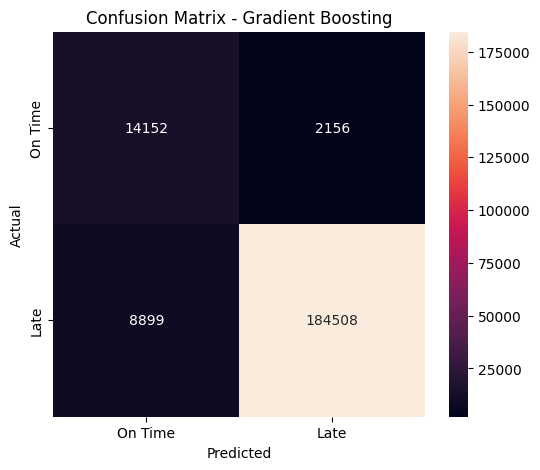

In [ ]:
# ============================================================
# MACHINE LEARNING - CELL B14
# Confusion Matrix
# ============================================================

best_model_name = results_df.loc[
    0,
    "Model"
]

best_predictions = predictions[
    best_model_name
]["prediction"]

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["On Time", "Late"],
    yticklabels=["On Time", "Late"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.show()

**Detailed classification report**

In [ ]:
# ============================================================
# MACHINE LEARNING - CELL B15
# Classification Report
# ============================================================

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            "On Time",
            "Late"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     On Time       0.61      0.87      0.72     16308
        Late       0.99      0.95      0.97    193407

    accuracy                           0.95    209715
   macro avg       0.80      0.91      0.85    209715
weighted avg       0.96      0.95      0.95    209715



**Generate risk probability**

In [ ]:
# ============================================================
# MACHINE LEARNING - CELL B16
# Select best model and calculate risk probability
# ============================================================

best_model = models[best_model_name]

all_probabilities = best_model.predict_proba(X)[:, 1]

df_ml["late_delivery_probability"] = all_probabilities

print(
    df_ml[
        [
            "late_delivery_probability"
        ]
    ].head(10)
)

   late_delivery_probability
0                   0.384449
1                   0.396580
2                   0.467625
3                   0.387470
4                   0.383460
5                   0.389883
6                   0.399098
7                   0.398756
8                   0.381423
9                   0.398756


**Create Risk Categories**

In [ ]:
# ============================================================
# MACHINE LEARNING - CELL B17
# Risk Categories
# ============================================================

def assign_risk(probability):

    if probability < 0.30:
        return "Low Risk"

    elif probability < 0.70:
        return "Medium Risk"

    else:
        return "High Risk"


df_ml["risk_category"] = (
    df_ml["late_delivery_probability"]
    .apply(assign_risk)
)

print(
    df_ml["risk_category"]
    .value_counts()
)

risk_category
High Risk      931601
Medium Risk    116764
Low Risk          210
Name: count, dtype: int64


**Final prediction file**

In [ ]:
# ============================================================
# MACHINE LEARNING - CELL B18
# Export final prediction dataset
# ============================================================

output_file = "APL_Logistics_Final_Risk_Predictions.xlsx"

df_ml.to_excel(
    output_file,
    index=False
)

print("Final file created successfully:")
print(output_file)